In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

In [2]:
df = pd.read_csv("german_credit_data.csv")

In [3]:
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


In [5]:
df.shape

(1000, 21)

In [6]:
df.describe()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,...,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,1.145000,...,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.845000,1.404000,1.963000,0.700000
std,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,0.477706,...,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856,0.458487
min,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,1.000000,...,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,1.000000,...,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000
50%,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,1.000000,...,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000
75%,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,1.000000,...,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000
max,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,3.000000,...,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000,1.000000


In [7]:
df.isnull().sum()

laufkont    0
laufzeit    0
moral       0
verw        0
hoehe       0
sparkont    0
beszeit     0
rate        0
famges      0
buerge      0
wohnzeit    0
verm        0
alter       0
weitkred    0
wohn        0
bishkred    0
beruf       0
pers        0
telef       0
gastarb     0
kredit      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

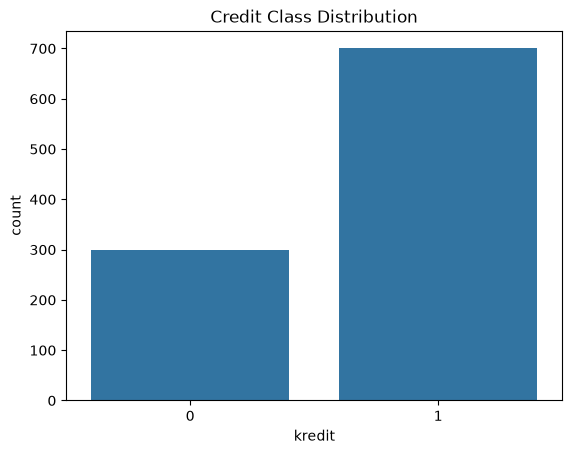

In [9]:
sns.countplot(x="kredit", data=df)

plt.title("Credit Class Distribution")

plt.show()

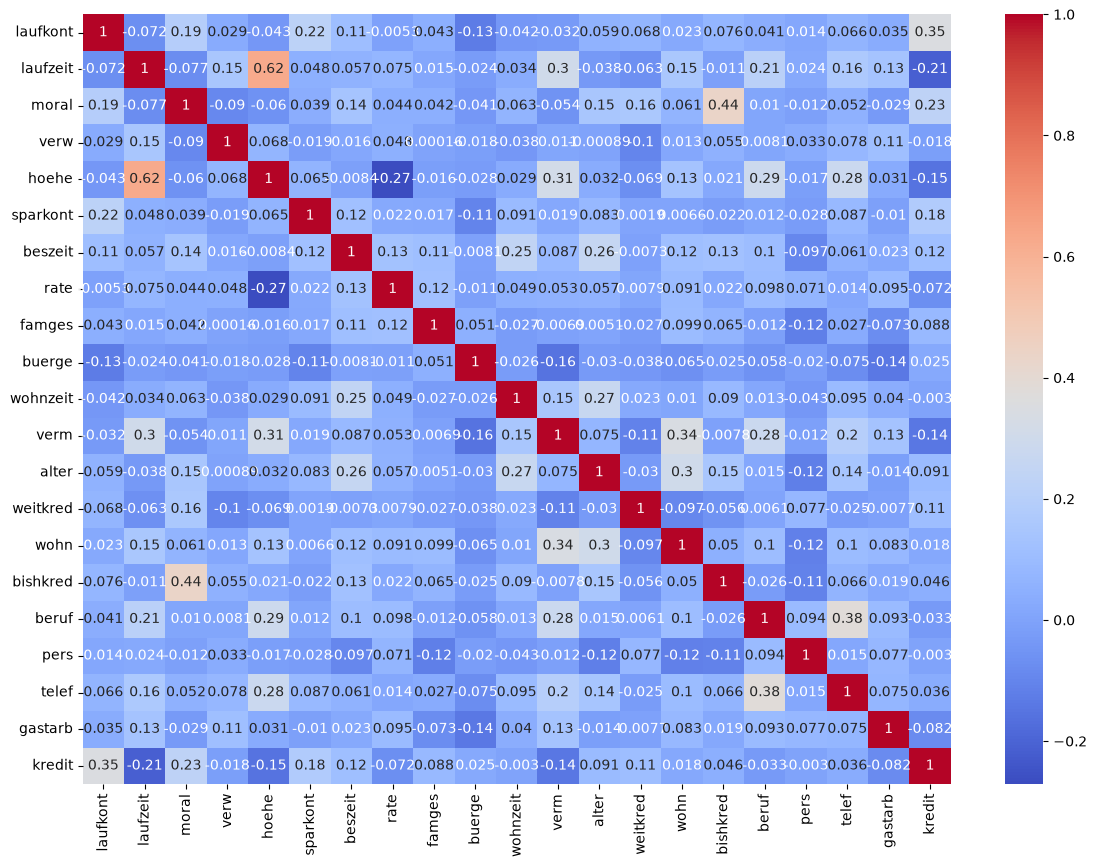

In [10]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

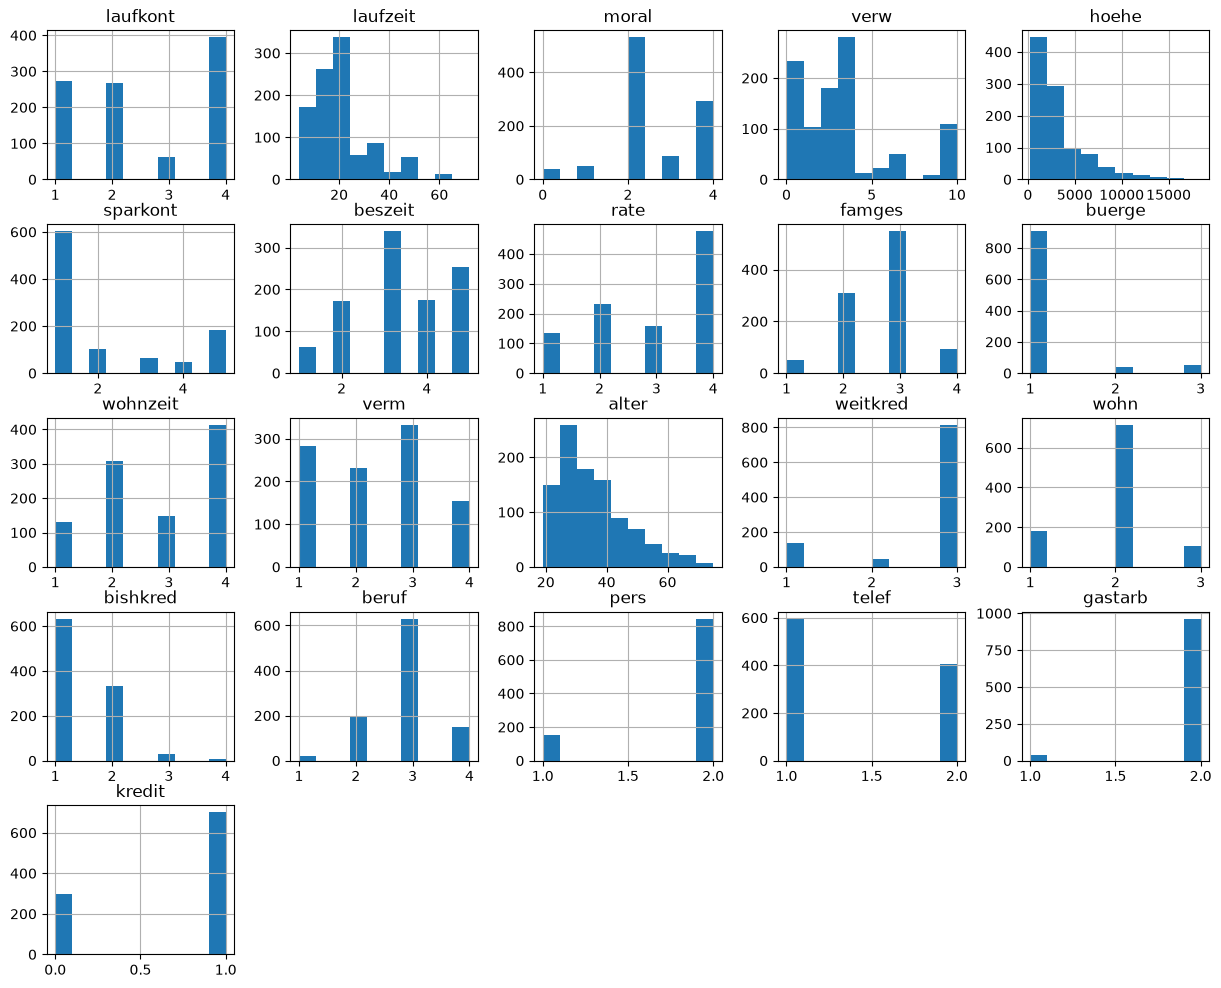

In [11]:
df.hist(figsize=(15,12))

plt.show()

In [12]:
X = df.drop("kredit", axis=1)

y = df["kredit"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [15]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [16]:
print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall   :", recall_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, pred_lr))

Accuracy : 0.75
Precision: 0.7784810126582279
Recall   : 0.8913043478260869
F1 Score : 0.831081081081081
ROC AUC  : 0.6633941093969145


In [17]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [18]:
print("Accuracy :", accuracy_score(y_test, pred_dt))
print("Precision:", precision_score(y_test, pred_dt))
print("Recall   :", recall_score(y_test, pred_dt))
print("F1 Score :", f1_score(y_test, pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, pred_dt))

Accuracy : 0.73
Precision: 0.8387096774193549
Recall   : 0.7536231884057971
F1 Score : 0.7938931297709924
ROC AUC  : 0.7155212716222534


In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [20]:
print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall   :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, pred_rf))

Accuracy : 0.735
Precision: 0.7707006369426752
Recall   : 0.8768115942028986
F1 Score : 0.8203389830508474
ROC AUC  : 0.648083216456288


In [21]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf)
    ],

    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_dt),
        precision_score(y_test,pred_rf)
    ],

    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_dt),
        recall_score(y_test,pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_dt),
        f1_score(y_test,pred_rf)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750,0.778481,0.891304,0.831081
1,Decision Tree,0.730,0.838710,0.753623,0.793893
2,Random Forest,0.735,0.770701,0.876812,0.820339


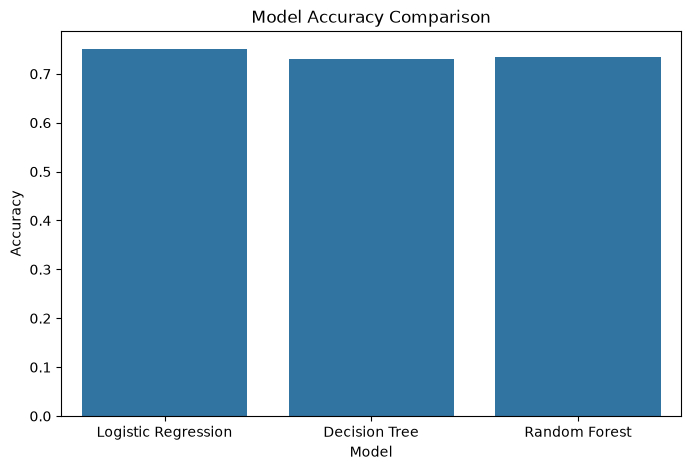

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Model Accuracy Comparison")

plt.show()

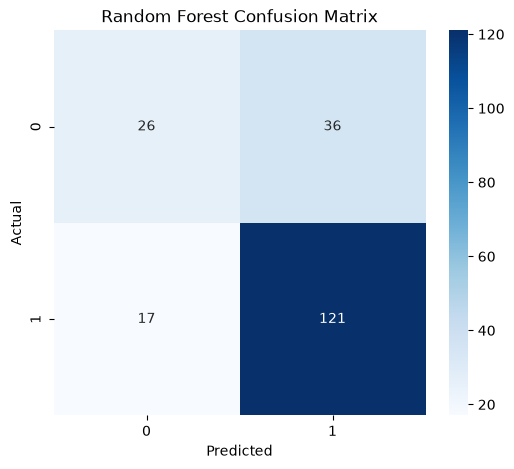

In [23]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [24]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.60      0.42      0.50        62
           1       0.77      0.88      0.82       138

    accuracy                           0.73       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.72      0.73      0.72       200



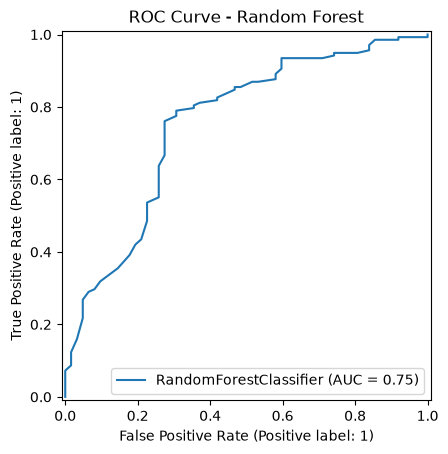

In [25]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)

plt.title("ROC Curve - Random Forest")

plt.show()

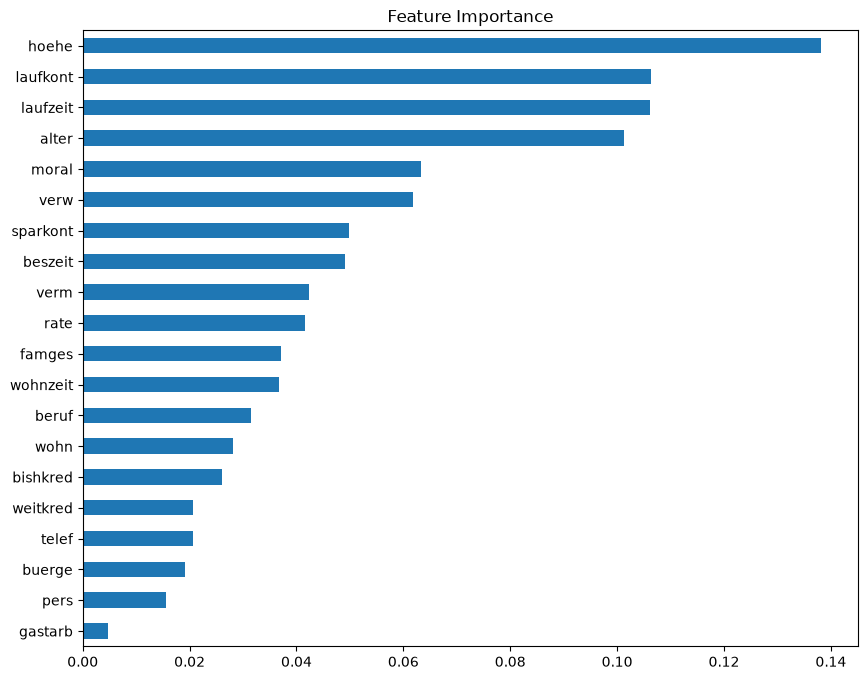

In [26]:
importance = pd.Series(rf.feature_importances_, index=df.columns[:-1])

importance.sort_values().plot(kind="barh", figsize=(10,8))

plt.title("Feature Importance")

plt.show()

In [33]:
sample = X_test[0].reshape(1, -1)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Customer is Creditworthy")
else:
    print("Customer is Not Creditworthy")

Customer is Not Creditworthy


In [28]:
import joblib

joblib.dump(rf, "credit_scoring_model.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [29]:
print(X.columns)
print("Number of features:", len(X.columns))

Index(['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit',
       'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred',
       'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb'],
      dtype='str')
Number of features: 20


In [30]:
print(new_customer.shape)

(1, 20)
